DATE to DATE_TIME

In [ ]:
# Convert Parquet to CSV

import pandas as pd

# Path to the CSV file
csv_file_path = r'total.csv'
neighbor = r'Data_bridge_ESFAHAN.Neighbors.csv'
# Read the CSV files
df = pd.read_csv(csv_file_path)
neighbors = pd.read_csv(neighbor)

# ✅ Create data_time column from DATE_KEY and HOUR_KEY
df['data_time'] = pd.to_datetime(df['DATE_KEY'].astype(str), format='%Y%m%d') + pd.to_timedelta(df['HOUR_KEY'], unit='h')

# ✅ Apply your rule:
# - Remove 3rd & 4th chars: [0:2] + [4:]
# - Remove last char: [:-1]

df['Mapped_ID'] = df['NE_NAME'].apply(
    lambda x: (x[0:2] + x[4:]).rstrip()[:-1]
)

print(df)
df.to_csv("merged_df",index =False)

C:\Users\Reza\AppData\Local\Temp\ipykernel_20892\3724822417.py:9: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_file_path)


         Unnamed: 0     NE_NAME                       KPI_NAME      VALUE  \
0                 0  ES2U1304B2  Average_RTWP_dbm(huawei_Cell) -103.63000   
1                 1  ES2U1304B2  Average_RTWP_dbm(huawei_Cell) -104.23806   
2                 2  ES2U1304B2  Average_RTWP_dbm(huawei_Cell) -104.93875   
3                 3  ES2U1304B2  Average_RTWP_dbm(huawei_Cell) -105.08086   
4                 4  ES2U1304B2  Average_RTWP_dbm(huawei_Cell) -105.28611   
...             ...         ...                            ...        ...   
8301464     8469289  ES3L0792D1    RSSI_PUSCH(Huawei_LTE_Cell) -115.23508   
8301465     8469290  ES3L0792D1    RSSI_PUSCH(Huawei_LTE_Cell) -115.71744   
8301466     8469291  ES3L0792D1    RSSI_PUSCH(Huawei_LTE_Cell) -115.71493   
8301467     8469292  ES3L0792D1    RSSI_PUSCH(Huawei_LTE_Cell) -115.84105   
8301468     8469293  ES3L0792D1    RSSI_PUSCH(Huawei_LTE_Cell) -116.03679   

         DATE_KEY  LATITUDE  LONGITUDE   BSC_RNC_NAME AZIMUTH  HOUR_KEY  \


In [2]:
df.to_csv("merged_df_mapID.csv",index =False)

Intersection between anomaly and RSSI

In [ ]:
# Read anomaly.csv file
anomaly_df = pd.read_csv('Analysis.csv')

# Merge anomaly_df and df (RSSI) based on anomaly_df['name'] == df['NE_NAME']
anomaly_merged = df.merge(anomaly_df, left_on='NE_NAME', right_on='name', how='inner')

# Filter only rows where NE_NAME is in anomaly_df['name']
anomaly_only = df[df['NE_NAME'].isin(anomaly_df['name'])]

# Save the filtered dataframe to a new CSV file
anomaly_only.to_csv('RSSI_with_anomalies.csv', index=False)


In [33]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.spatial.distance import pdist, squareform
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from dtaidistance import dtw
import ruptures as rpt
from statsmodels.tsa.stattools import grangercausalitytests
import warnings
warnings.filterwarnings('ignore')

class PathLossWeightedCoehaviorAnalyzer:
    def __init__(self, path_loss_threshold=130, similarity_threshold=0.7, 
                 causality_threshold=0.05, min_cluster_size=2):
        """
        Initialize the analyzer with configurable thresholds
        
        Parameters:
        - path_loss_threshold: Maximum path loss (dB) to consider sectors as connected
        - similarity_threshold: Minimum similarity score for clustering
        - causality_threshold: P-value threshold for Granger causality
        - min_cluster_size: Minimum sectors in a cluster
        """
        self.path_loss_threshold = path_loss_threshold
        self.similarity_threshold = similarity_threshold
        self.causality_threshold = causality_threshold
        self.min_cluster_size = min_cluster_size
        
    def calculate_influence_weights(self, path_loss_matrix):
        """
        Convert path loss to influence weights
        Lower path loss = higher influence
        """
        # Create boolean mask for valid connections
        valid_connections = path_loss_matrix <= self.path_loss_threshold
        
        # Calculate influence weights (inverse relationship with path loss)
        influence_weights = np.zeros_like(path_loss_matrix)
        
        # For valid connections, use exponential decay based on path loss
        mask = valid_connections & (path_loss_matrix > 0)
        influence_weights[mask] = np.exp(-path_loss_matrix[mask] / 40)  # 40dB decay constant
        
        # Set diagonal to 0 (sector doesn't influence itself)
        np.fill_diagonal(influence_weights, 0)
        
        return influence_weights, valid_connections
    
    def calculate_rtwp_changes(self, rtwp_timeseries):
        """
        Calculate various change metrics for RTWP time series
        """
        # First difference (hourly changes)
        hourly_changes = np.diff(rtwp_timeseries)
        
        # Second difference (acceleration)
        acceleration = np.diff(hourly_changes)
        
        # Rolling standard deviation (volatility)
        volatility = pd.Series(rtwp_timeseries).rolling(window=6).std().fillna(0).values
        
        # Cumulative deviation from daily mean
        daily_mean = np.mean(rtwp_timeseries)
        cumulative_deviation = np.cumsum(rtwp_timeseries - daily_mean)
        
        return {
            'hourly_changes': hourly_changes,
            'acceleration': acceleration,
            'volatility': volatility,
            'cumulative_deviation': cumulative_deviation,
            'daily_mean': daily_mean
        }
    
    def calculate_weighted_similarity(self, sector_data, neighbor_data, influence_weight):
        """
        Calculate weighted similarity between sector and neighbor RTWP patterns
        """
        # Ensure same length
        min_len = min(len(sector_data), len(neighbor_data))
        sector_data = sector_data[:min_len]
        neighbor_data = neighbor_data[:min_len]
        
        # Calculate multiple similarity metrics
        similarities = {}
        
        # 1. Pearson correlation of raw values
        if len(sector_data) > 3:
            pearson_corr, p_value = stats.pearsonr(sector_data, neighbor_data)
            similarities['pearson'] = abs(pearson_corr) if not np.isnan(pearson_corr) else 0
        else:
            similarities['pearson'] = 0
        
        # 2. Spearman correlation (rank-based)
        if len(sector_data) > 3:
            spearman_corr, _ = stats.spearmanr(sector_data, neighbor_data)
            similarities['spearman'] = abs(spearman_corr) if not np.isnan(spearman_corr) else 0
        else:
            similarities['spearman'] = 0
        
        # 3. DTW distance for pattern similarity
        try:
            dtw_distance = dtw.distance(sector_data, neighbor_data)
            max_possible_dtw = len(sector_data) * max(np.std(sector_data), np.std(neighbor_data))
            dtw_similarity = 1 - min(dtw_distance / max_possible_dtw, 1) if max_possible_dtw > 0 else 0
            similarities['dtw'] = dtw_similarity
        except:
            similarities['dtw'] = 0
        
        # 4. Change pattern similarity
        sector_changes = np.diff(sector_data)
        neighbor_changes = np.diff(neighbor_data)
        print(neighbor_changes)
        if len(sector_changes) > 1:
            change_corr, _ = stats.pearsonr(sector_changes, neighbor_changes)
            similarities['change_pattern'] = abs(change_corr) if not np.isnan(change_corr) else 0
        else:
            similarities['change_pattern'] = 0
        
        # 5. Synchronization of extreme events
        sector_extremes = np.abs(sector_data - np.mean(sector_data)) > 2 * np.std(sector_data)
        neighbor_extremes = np.abs(neighbor_data - np.mean(neighbor_data)) > 2 * np.std(neighbor_data)
        if np.any(sector_extremes) or np.any(neighbor_extremes):
            sync_score = np.mean(sector_extremes == neighbor_extremes)
            similarities['synchronization'] = sync_score
        else:
            similarities['synchronization'] = 0
        
        # Combined weighted similarity
        weights = {
            'pearson': 0.15,
            'spearman': 0.10,
            'dtw': 0.15,
            'change_pattern': 0.50,
            'synchronization': 0.10
        }
        
        combined_similarity = sum(similarities[key] * weights[key] for key in weights)
        
        # Apply path loss weighting
        weighted_similarity = combined_similarity * influence_weight
        
        return weighted_similarity, similarities
    
    def detect_change_points(self, rtwp_data):
        """
        Detect change points in RTWP time series
        """
        try:
            # Use Pelt algorithm for change point detection
            algo = rpt.Pelt(model="rbf").fit(rtwp_data)
            change_points = algo.predict(pen=10)
            return change_points[:-1]  # Remove last point (end of series)
        except:
            return []
    
    def test_granger_causality(self, cause_series, effect_series, max_lag=6):
        """
        Test Granger causality between two time series
        """
        try:
            # Prepare data (effect, cause)
            data = np.column_stack([effect_series, cause_series])
            
            # Ensure minimum length
            if len(data) < 2 * max_lag + 1:
                return False, 1.0
            
            # Test causality
            gc_result = grangercausalitytests(data, max_lag, verbose=False)
            
            # Get minimum p-value across all lags
            p_values = [gc_result[i+1][0]['ssr_ftest'][1] for i in range(max_lag)]
            min_p_value = min(p_values)
            
            is_causal = min_p_value < self.causality_threshold
            
            return is_causal, min_p_value
            
        except Exception as e:
            return False, 1.0
    
    def analyze_daily_anomalies(self, rtwp_data, path_loss_matrix, anomaly_sectors, sector_ids):
        """
        Main analysis function for daily anomaly detection
        
        Parameters:
        - rtwp_data: dict {sector_id: hourly_rtwp_values}
        - path_loss_matrix: 2D array of path loss values between sectors
        - anomaly_sectors: list of sector IDs detected as anomalous
        - sector_ids: list of all sector IDs in order matching path_loss_matrix
        
        Returns:
        - Analysis results with clusters and propagation patterns
        """
        # Calculate influence weights
        influence_weights, valid_connections = self.calculate_influence_weights(path_loss_matrix)
        
        # Create sector ID to index mapping
        sector_to_idx = {sector_id: idx for idx, sector_id in enumerate(sector_ids)}
        
        results = {
            'clusters': {},
            'propagation_analysis': {},
            'similarity_matrix': {},
            'causality_results': {},
            'affected_sectors': set()
        }
        
        # For each anomalous sector, analyze its influence network
        for anomaly_sector in anomaly_sectors:
            if anomaly_sector not in sector_to_idx:
                continue
                
            anomaly_idx = sector_to_idx[anomaly_sector]
            anomaly_data = rtwp_data[anomaly_sector]
            
            # Find sectors within path loss threshold
            connected_sectors = []
            for i, sector_id in enumerate(sector_ids):
                if (i != anomaly_idx and 
                    valid_connections[anomaly_idx, i] and 
                    sector_id in rtwp_data):
                    connected_sectors.append((sector_id, i))
            
            # Calculate similarities with connected sectors
            similarities = {}
            causality_results = {}
            
            for sector_id, sector_idx in connected_sectors:
                neighbor_data = rtwp_data[sector_id]
                influence_weight = influence_weights[anomaly_idx, sector_idx]
                
                # Calculate weighted similarity
                weighted_sim, detailed_sims = self.calculate_weighted_similarity(
                    anomaly_data, neighbor_data, influence_weight
                )
                
                similarities[sector_id] = {
                    'weighted_similarity': weighted_sim,
                    'raw_similarity': detailed_sims,
                    'influence_weight': influence_weight,
                    'path_loss': path_loss_matrix[anomaly_idx, sector_idx]
                }
                
                # Test Granger causality
                is_causal, p_value = self.test_granger_causality(
                    anomaly_data, neighbor_data
                )
                causality_results[sector_id] = {
                    'is_causal': is_causal,
                    'p_value': p_value
                }
            
            # Identify affected sectors (high similarity or causal relationship)
            affected_sectors = []
            for sector_id in similarities:
                sim_score = similarities[sector_id]['weighted_similarity']
                is_causal = causality_results[sector_id]['is_causal']
                
                # Sector is affected if:
                # 1. High similarity score, OR
                # 2. Significant causal relationship, OR
                # 3. Moderate similarity with strong path loss connection
                if (sim_score >= self.similarity_threshold or 
                    is_causal or 
                    (sim_score >= 0.5 and similarities[sector_id]['influence_weight'] >= 0.5)):
                    affected_sectors.append(sector_id)
                    results['affected_sectors'].add(sector_id)
            
            # Store results for this anomaly sector
            results['clusters'][anomaly_sector] = affected_sectors
            results['similarity_matrix'][anomaly_sector] = similarities
            results['causality_results'][anomaly_sector] = causality_results
            
            # Propagation analysis
            propagation_analysis = {
                'primary_affected': [s for s in affected_sectors 
                                   if similarities[s]['weighted_similarity'] >= 0.8],
                'secondary_affected': [s for s in affected_sectors 
                                     if 0.5 <= similarities[s]['weighted_similarity'] < 0.8],
                'causal_affected': [s for s in affected_sectors 
                                  if causality_results[s]['is_causal']],
                'total_affected_count': len(affected_sectors),
                'max_similarity': max([similarities[s]['weighted_similarity'] 
                                     for s in similarities] + [0]),
                'avg_path_loss': np.mean([similarities[s]['path_loss'] 
                                        for s in affected_sectors] + [0])
            }
            
            results['propagation_analysis'][anomaly_sector] = propagation_analysis
        
        return results
    
    def generate_report(self, results, anomaly_sectors):
        """
        Generate human-readable analysis report
        """
        report = []
        report.append("=== DAILY ANOMALY CO-BEHAVIOR ANALYSIS REPORT ===\n")
        
        total_affected = len(results['affected_sectors'])
        report.append(f"Total sectors analyzed: {len(anomaly_sectors)}")
        report.append(f"Total additional sectors affected: {total_affected}")
        report.append(f"Average affected sectors per anomaly: {total_affected/len(anomaly_sectors):.1f}\n")
        
        for anomaly_sector in anomaly_sectors:
            if anomaly_sector not in results['clusters']:
                continue
                
            cluster = results['clusters'][anomaly_sector]
            propagation = results['propagation_analysis'][anomaly_sector]
            
            report.append(f"\n--- ANOMALY SECTOR: {anomaly_sector} ---")
            report.append(f"Affected sectors: {len(cluster)}")
            report.append(f"Primary affected: {len(propagation['primary_affected'])}")
            report.append(f"Secondary affected: {len(propagation['secondary_affected'])}")
            report.append(f"Causal relationships: {len(propagation['causal_affected'])}")
            report.append(f"Max similarity score: {propagation['max_similarity']:.3f}")
            report.append(f"Avg path loss to affected: {propagation['avg_path_loss']:.1f} dB")
            
            if cluster:
                report.append(f"Affected sector list: {', '.join(map(str, cluster))}")
        
        return "\n".join(report)

# Example usage function
def run_daily_analysis(rtwp_data, path_loss_matrix, anomaly_sectors, sector_ids):
    """
    Run the complete daily anomaly analysis
    
    Parameters:
    - rtwp_data: dict {sector_id: [24 hourly RTWP values]}
    - path_loss_matrix: 2D numpy array (30x30) of path loss values
    - anomaly_sectors: list of sector IDs detected as anomalous
    - sector_ids: list of 30 sector IDs matching path_loss_matrix order
    
    Returns:
    - results: detailed analysis results
    - report: human-readable report
    """
    # Initialize analyzer
    analyzer = PathLossWeightedCoehaviorAnalyzer(
        path_loss_threshold=130,  # dB
        similarity_threshold=0.7,
        causality_threshold=0.05,
        min_cluster_size=2
    )
    
    # Run analysis
    results = analyzer.analyze_daily_anomalies(
        rtwp_data, path_loss_matrix, anomaly_sectors, sector_ids
    )
    
    # Generate report
    report = analyzer.generate_report(results, anomaly_sectors)
    
    return results, report

# Example data structure for testing
def create_example_data():
    """
    Create example data structure for testing
    """
    # 30 sectors with 24 hourly RTWP values each
    np.random.seed(42)
    rtwp_data = {}
    
    for i in range(30):
        sector_id = f"sector_{i:02d}"
        # Generate realistic RTWP values (-120 to -70 dBm)
        base_rtwp = np.random.normal(-95, 10, 24)
        
        # Add some correlation structure for testing
        if i < 5:  # First 5 sectors have correlated anomalies
            anomaly_pattern = np.sin(np.linspace(0, 4*np.pi, 24)) * 5
            base_rtwp += anomaly_pattern
        
        rtwp_data[sector_id] = base_rtwp
    
    # Path loss matrix (30x30) - realistic path loss values
    path_loss_matrix = np.random.uniform(80, 140, (30, 30))
    np.fill_diagonal(path_loss_matrix, 0)  # No self path loss
    
    # Make matrix symmetric (path loss A->B = B->A)
    path_loss_matrix = (path_loss_matrix + path_loss_matrix.T) / 2
    
    # Sector IDs
    sector_ids = [f"sector_{i:02d}" for i in range(30)]
    
    # Example anomalous sectors
    anomaly_sectors = ["sector_00", "sector_01", "sector_02"]
    
    return rtwp_data, path_loss_matrix, anomaly_sectors, sector_ids

#if __name__ == "__main__":
    #rtwp_data, path_loss_matrix, anomaly_sectors, sector_ids = create_example_data()
    #anamoly_df = pd.read_csv('28.csv')
    #anamoly_sectors = anamoly_df['name'].tolist()

    #print(f"rtwp_data:{rtwp_data}, path_loss_matrix:{path_loss_matrix}, anomaly_sectors:{anomaly_sectors}, sector_ids:{sector_ids}")
    #results, report = run_daily_analysis( rtwp_data, path_loss_matrix, anomaly_sectors, sector_ids)
    #print(results,report)

In [ ]:
import numpy as np
import pandas as pd

def prepare_inputs_for_date(rtwp_csv, pathloss_csv, anomaly_csv, target_date):
    """
    Load and prepare inputs for a specific date, using only Mapped_ID as identifiers.
    - rtwp_data: dict {mapped_id: hourly VALUE array for target_date}
    - path_loss_matrix: numpy array (M x M)
    - anomaly_sectors: list of mapped_id strings for anomalies
    - sector_ids: list of mapped_id strings that have data & neighbors
    """
    # 1) Load raw DataFrames
    rtwp_df = pd.read_csv(rtwp_csv, low_memory=False)
    pathloss_df = pd.read_csv(pathloss_csv)
    anom_df = pd.read_csv(anomaly_csv, parse_dates=['DATE_KEY'])
    
    # 2) Compute Mapped_ID
    rtwp_df['Mapped_ID'] = rtwp_df['NE_NAME'].str[:2] + rtwp_df['NE_NAME'].str[4:-1]
    anom_df['Mapped_ID'] = anom_df['name'].str[:2] + anom_df['name'].str[4:-1]
    
    # 3) Extract anomaly mapped IDs
    anomaly_sectors = anom_df['Mapped_ID'].unique().tolist()
    print("Anomaly DF columns:", anom_df.columns.tolist())
    print("Mapped anomalies:", anomaly_sectors)
    # 4) Build DATETIME and filter to target_date
    rtwp_df['DATE_KEY'] = rtwp_df['DATE_KEY'].astype(str)
    rtwp_df['HOUR_KEY'] = rtwp_df['HOUR_KEY'].astype(int).astype(str).str.zfill(2)
    dt_series = rtwp_df['DATE_KEY'] + rtwp_df['HOUR_KEY']
    rtwp_df['DATETIME'] = pd.to_datetime(dt_series, format='%Y%m%d%H', errors='coerce')
    # filter by date
    rtwp_date = rtwp_df[rtwp_df['DATE_KEY'] == target_date]
    print(rtwp_date.head())
    # 5) Filter pathloss to only anomaly mapped sectors, keep rank ≤ 30
    pathloss_df = pathloss_df[pathloss_df['rank'] <= 30]
    rel_pl = pathloss_df[pathloss_df['Sector'].isin(anomaly_sectors)]
    
    # 6) Sector_ids initial from rel_pl
    candidate_ids = pd.unique(rel_pl[['Sector', 'Neighbor']].values.ravel()).tolist()
    print("Candidate IDs from pathloss:", candidate_ids)

    # 7) Keep only those candidate_ids present in rtwp_date
    available_ids = rtwp_date['Mapped_ID'].unique().tolist()
    sector_ids = [mid for mid in candidate_ids if mid in available_ids]
    print("Final sector_ids:", sector_ids)

    # 8) Re-filter rel_pl to rows where both Sector and Neighbor in sector_ids
    rel_pl = rel_pl[
        rel_pl['Sector'].isin(sector_ids) &
        rel_pl['Neighbor'].isin(sector_ids)
    ]
    
    # 9) Build path loss matrix
    M = len(sector_ids)
    pl_mat = np.full((M, M), np.inf)
    for _, row in rel_pl.iterrows():
        i = sector_ids.index(row['Sector'])
        j = sector_ids.index(row['Neighbor'])
        pl_mat[i, j] = row['pathloss']
    pl_mat = np.minimum(pl_mat, pl_mat.T)
    np.fill_diagonal(pl_mat, 0.0)
    
    # 10) Build rtwp_data dict for target_date
    rtwp_data = {}
    for mid in sector_ids:
        vals = (rtwp_date[rtwp_date['Mapped_ID'] == mid]
                .sort_values('DATETIME')['VALUE']
                .to_numpy(dtype=float))
        # Only include if full 24 hours present
        if len(vals) == 24:
        rtwp_data[mid] = vals
    
    # 11) Drop any sector_ids without 24-value series
    sector_ids = list(rtwp_data.keys())

    return rtwp_data, pl_mat, anomaly_sectors, sector_ids


rtwp_data, path_loss_matrix, anomaly_sectors, sector_ids = prepare_inputs_for_date(
    rtwp_csv='Esfehan_RSSI_merged.csv',
    pathloss_csv='Data_bridge_ESFAHAN.Neighbors_3G_3G.csv',
    anomaly_csv='2.csv',
    target_date='20250702'
)
print("RTWP Data:", rtwp_data)
print("Path Loss Matrix:", path_loss_matrix)
print("Anomaly Sectors:", anomaly_sectors)
print("Sector IDs:", sector_ids)
'''
    print("RTWP Data:", rtwp_data)
    print("Path Loss Matrix:", path_loss_matrix)
    print("Anomaly Sectors:", anomaly_sectors)
    print("Sector IDs:", sector_ids)
'''
    # Now you can pass these into run_daily_analysis(...)
    # results, report = run_daily_analysis(rtwp_data, path_loss_matrix, anomaly_sectors, sector_ids)
'''
    results, report = run_daily_analysis(
        rtwp_data=rtwp_data,
        path_loss_matrix=path_loss_matrix,
        anomaly_sectors=anomaly_sectors,
        sector_ids=sector_ids
    )
    print("Results:", results)
    print("Report:", report)
    with open("daily_analysis_report.txt", "w") as f:
        f.write(str(report))
    with open("daily_analysis_results.txt", "w") as f:
        f.write(str(results))
'''


Anomaly DF columns: ['key', 'id', 'name', '_id', 'DATE_KEY', 'BSC_RNC_NAME', 'KPI_NAME', 'STD', 'Last_day_Diff', 'CHANGE_TYPE', 'Repeated', 'Province', 'mean', 'azimuth', 'latitude', 'longitude', 'Mapped_ID']
Mapped anomalies: ['ES0331B', 'ES0022A', 'ES0567A', 'ES0300D', 'ES1322C', 'ES0234D']
     Unnamed: 0     NE_NAME                       KPI_NAME      VALUE  \
96           96  ES2U1304B2  Average_RTWP_dbm(huawei_Cell) -103.99903   
97           97  ES2U1304B2  Average_RTWP_dbm(huawei_Cell) -103.93540   
98           98  ES2U1304B2  Average_RTWP_dbm(huawei_Cell) -104.15653   
99           99  ES2U1304B2  Average_RTWP_dbm(huawei_Cell) -105.02500   
100         100  ES2U1304B2  Average_RTWP_dbm(huawei_Cell) -105.26000   

     DATE_KEY  LATITUDE  LONGITUDE   BSC_RNC_NAME AZIMUTH HOUR_KEY  \
96   20250702  32.33563   51.52099  Esfahan_R315H     170       00   
97   20250702  32.33563   51.52099  Esfahan_R315H     170       01   
98   20250702  32.33563   51.52099  Esfahan_R315H     170

'\n    results, report = run_daily_analysis(\n        rtwp_data=rtwp_data,\n        path_loss_matrix=path_loss_matrix,\n        anomaly_sectors=anomaly_sectors,\n        sector_ids=sector_ids\n    )\n    print("Results:", results)\n    print("Report:", report)\n    with open("daily_analysis_report.txt", "w") as f:\n        f.write(str(report))\n    with open("daily_analysis_results.txt", "w") as f:\n        f.write(str(results))\n'

In [ ]:
print("RTWP Data:", rtwp_data)
print("Path Loss Matrix:", path_loss_matrix)
print("Anomaly Sectors:", anomaly_sectors)
print("Sector IDs:", sector_ids)
#print("Length of 'ES0022A' in rtwp_data:", len(rtwp_data["ES1532D"]))


RTWP Data: {}
Path Loss Matrix: [[  0.         136.58256553 133.58256553 ...          inf          inf
           inf]
 [136.58256553   0.                  inf ...          inf          inf
           inf]
 [133.58256553          inf   0.         ...          inf          inf
           inf]
 ...
 [         inf          inf          inf ...   0.                  inf
           inf]
 [         inf          inf          inf ...          inf   0.
           inf]
 [         inf          inf          inf ...          inf          inf
    0.        ]]
Anomaly Sectors: ['ES0331B', 'ES0022A', 'ES0567A', 'ES0300D', 'ES1322C', 'ES0234D']
Sector IDs: []


In [42]:
def prepare_rtwp_data(rtwp_df, target_date):
   """Convert RTWP dataframe to required format using Mapped_ID for specific date"""
   rtwp_data = {}
   
   # Filter for specific date first
   daily_data = rtwp_df[rtwp_df['DATE_KEY'] == target_date]
   
   # Group by Mapped_ID and HOUR_KEY, take mean of VALUE
   grouped = daily_data.groupby(['Mapped_ID', 'HOUR_KEY'])['VALUE'].mean().reset_index()
   
   for mapped_id in grouped['Mapped_ID'].unique():
       sector_data = grouped[grouped['Mapped_ID'] == mapped_id].sort_values('HOUR_KEY')
       if len(sector_data) == 24:  # Ensure complete 24-hour data
           rtwp_data[mapped_id] = sector_data['VALUE'].values
   
   return rtwp_data

def prepare_path_loss_matrix(path_loss_df, sector_ids):
   """Create path loss matrix from dataframe - only include sectors that exist in RTWP"""
   # Filter path loss data to only include sectors that exist in RTWP data
   filtered_pathloss = path_loss_df[
       (path_loss_df['Sector'].isin(sector_ids)) & 
       (path_loss_df['Neighbor'].isin(sector_ids))
   ]
   
   # Create mapping for sector positions
   id_to_idx = {sector_id: idx for idx, sector_id in enumerate(sector_ids)}
   
   # Initialize matrix with high values (no connection)
   matrix = np.full((len(sector_ids), len(sector_ids)), 999.0)
   np.fill_diagonal(matrix, 0)
   
   # Fill matrix with actual path loss values
   for _, row in filtered_pathloss.iterrows():
       sector = row['Sector']
       neighbor = row['Neighbor'] 
       path_loss = row['pathloss']
       
       i, j = id_to_idx[sector], id_to_idx[neighbor]
       matrix[i, j] = path_loss
       matrix[j, i] = path_loss  # Make symmetric
   
   return matrix

def prepare_inputs(rtwp_df, path_loss_df, anomaly_df, target_date):
   """Main function to prepare all inputs for specific date"""
   # Get RTWP data for specific date
   rtwp_data = prepare_rtwp_data(rtwp_df, target_date)
   
   # Get all unique sector IDs that have RTWP data
   sector_ids = list(rtwp_data.keys())
   
   # Create path loss matrix (only for sectors with RTWP data)
   path_loss_matrix = prepare_path_loss_matrix(path_loss_df, sector_ids)
   
   # Filter anomaly sectors for specific date and only those with RTWP data
   daily_anomalies = anomaly_df[anomaly_df['DATE_KEY'] == target_date]
   anomaly_sectors = [sector for sector in daily_anomalies['name'].tolist() 
                     if sector in rtwp_data]
   
   return rtwp_data, path_loss_matrix, anomaly_sectors, sector_ids



In [43]:
# Load your data
rtwp_df = pd.read_csv('Esfehan_RSSI_merged.csv')
path_loss_df = pd.read_csv('Data_bridge_ESFAHAN.Neighbors_3G_3G.csv')  
anomaly_df = pd.read_csv('2.csv')

# Prepare inputs
# Usage
rtwp_data, path_loss_matrix, anomaly_sectors, sector_ids = prepare_inputs(
   rtwp_df, path_loss_df, anomaly_df, target_date=20250702
)
print("RTWP Data:", rtwp_data)
print("Path Loss Matrix:", path_loss_matrix)
print("Anomaly Sectors:", anomaly_sectors)
print("Sector IDs:", sector_ids)
print("Length of 'ES0022A' in rtwp_data:", len(rtwp_data["ES1532D"]))
# Run analysis


RTWP Data: {'ES0001': array([0.       , 0.       , 0.0490475, 0.       , 0.       , 0.       ,
       0.       , 0.048225 , 1.1584725, 0.608415 , 0.89601  , 1.661085 ,
       0.196575 , 0.3338275, 0.01779  , 0.       , 0.       , 0.005295 ,
       0.0120025, 0.4412525, 0.09516  , 3.6315925, 0.317295 , 1.628485 ]), 'ES0001A': array([-106.63502462, -107.17237769, -108.10183923, -108.57996154,
       -108.79553   , -108.45513769, -108.46366692, -108.31393846,
       -107.73523692, -106.56294   , -105.69779538, -104.30932   ,
       -104.81511462, -105.70421308, -105.91534615,  -93.39247667,
       -104.10830154, -105.60708692, -105.79219077,  -92.39947667,
       -105.74226   , -106.05237   , -105.52208077, -105.91147769]), 'ES0001B': array([-108.14710923, -108.99515615, -110.04353231, -110.74505615,
       -110.69620769, -110.44147846, -110.21104385, -110.15174692,
       -109.11285   , -108.28401615, -106.90974846, -104.70706692,
       -105.23427462, -106.71111462, -107.07860077,  -96.

KeyError: 'ES1532D'

In [38]:
print("Number of Sector IDs:", len(sector_ids))

Number of Sector IDs: 7081


In [34]:
import pandas as pd
import numpy as np
from collections import defaultdict

class DataProcessor:
    def __init__(self):
        self.sector_to_index = {}
        self.index_to_sector = {}
        
    def process_path_loss_data(self, path_loss_df):
        """
        Process path loss CSV data to create path loss matrix
        
        Expected columns: id, Sector, Neighbor, rank, distance, pathloss, ring, type
        """
        # Get unique sectors (both as Sector and Neighbor)
        all_sectors = set(path_loss_df['Sector'].unique()) | set(path_loss_df['Neighbor'].unique())
        all_sectors = sorted(list(all_sectors))
        
        # Create sector to index mapping
        self.sector_to_index = {sector: idx for idx, sector in enumerate(all_sectors)}
        self.index_to_sector = {idx: sector for idx, sector in enumerate(all_sectors)}
        
        n_sectors = len(all_sectors)
        
        # Initialize path loss matrix with high values (no connection)
        path_loss_matrix = np.full((n_sectors, n_sectors), 999.0)  # 999 dB = no connection
        
        # Fill diagonal with 0 (sector to itself)
        np.fill_diagonal(path_loss_matrix, 0.0)
        
        # Fill matrix with actual path loss values
        for _, row in path_loss_df.iterrows():
            sector = row['Sector']
            neighbor = row['Neighbor']
            pathloss = row['pathloss']
            
            if sector in self.sector_to_index and neighbor in self.sector_to_index:
                sector_idx = self.sector_to_index[sector]
                neighbor_idx = self.sector_to_index[neighbor]
                
                # Set path loss (make it symmetric)
                path_loss_matrix[sector_idx, neighbor_idx] = pathloss
                path_loss_matrix[neighbor_idx, sector_idx] = pathloss
        
        return path_loss_matrix, all_sectors
    
    def process_rtwp_data(self, rtwp_df, target_date, mapped_id_column='Mapped_ID', ne_name_column='NE_NAME'):
        """
        Process RTWP CSV data to create hourly time series
        
        Expected columns: Unnamed: 0, NE_NAME, KPI_NAME, VALUE, DATE_KEY, LATITUDE, LONGITUDE, 
                         BSC_RNC_NAME, AZIMUTH, HOUR_KEY, data_time, Mapped_ID
        """
        # Filter for target date
        rtwp_df['DATE_KEY'] = pd.to_datetime(rtwp_df['DATE_KEY'], format='%Y%m%d')
        target_date = pd.to_datetime(target_date)
        daily_data = rtwp_df[rtwp_df['DATE_KEY'] == target_date].copy()
        
        if daily_data.empty:
            raise ValueError(f"No data found for date {target_date}")
        
        # Decide which column to use for sector identification
        # Priority: Mapped_ID (if exists and not null) -> NE_NAME
        if mapped_id_column in daily_data.columns:
            daily_data['sector_id'] = daily_data[mapped_id_column].fillna(daily_data[ne_name_column])
        else:
            daily_data['sector_id'] = daily_data[ne_name_column]
        
        # Create hourly RTWP data structure
        rtwp_hourly = {}
        
        # Group by sector and create 24-hour arrays
        for sector_id, group in daily_data.groupby('sector_id'):
            # Sort by hour to ensure proper order
            group_sorted = group.sort_values('HOUR_KEY')
            
            # Create 24-hour array (initialize with NaN)
            hourly_values = np.full(24, np.nan)
            
            # Fill available hours
            for _, row in group_sorted.iterrows():
                hour = int(row['HOUR_KEY'])
                if 0 <= hour <= 23:
                    hourly_values[hour] = float(row['VALUE'])
            
            # Only include sectors with sufficient data (at least 12 hours)
            valid_hours = ~np.isnan(hourly_values)
            if np.sum(valid_hours) >= 12:
                # Interpolate missing hours
                hourly_values = self._interpolate_missing_hours(hourly_values)
                rtwp_hourly[str(sector_id)] = hourly_values
        
        return rtwp_hourly
    
    def _interpolate_missing_hours(self, hourly_values):
        """
        Simple linear interpolation for missing hours
        """
        # Convert to pandas Series for easy interpolation
        series = pd.Series(hourly_values)
        
        # Forward fill, backward fill, then linear interpolation
        series = series.fillna(method='ffill').fillna(method='bfill')
        series = series.interpolate(method='linear')
        
        return series.values
    
    def match_sectors_with_path_loss(self, rtwp_data, path_loss_sectors):
        """
        Match RTWP sectors with path loss sectors and create aligned inputs
        """
        # Find sectors that exist in both datasets
        rtwp_sectors = set(rtwp_data.keys())
        path_loss_sectors_set = set(path_loss_sectors)
        
        # Find intersection
        common_sectors = rtwp_sectors & path_loss_sectors_set
        
        print(f"RTWP sectors: {len(rtwp_sectors)}")
        print(f"Path loss sectors: {len(path_loss_sectors_set)}")
        print(f"Common sectors: {len(common_sectors)}")
        
        if len(common_sectors) < 5:
            print("WARNING: Very few matching sectors found!")
            print("RTWP sample sectors:", list(rtwp_sectors)[:5])
            print("Path loss sample sectors:", path_loss_sectors[:5])
        
        # Create aligned data
        aligned_sectors = sorted(list(common_sectors))
        aligned_rtwp_data = {sector: rtwp_data[sector] for sector in aligned_sectors}
        
        # Create aligned path loss matrix
        aligned_path_loss_matrix = np.zeros((len(aligned_sectors), len(aligned_sectors)))
        
        for i, sector1 in enumerate(aligned_sectors):
            for j, sector2 in enumerate(aligned_sectors):
                idx1 = self.sector_to_index[sector1]
                idx2 = self.sector_to_index[sector2]
                aligned_path_loss_matrix[i, j] = path_loss_matrix[idx1, idx2]
        
        return aligned_rtwp_data, aligned_path_loss_matrix, aligned_sectors
    
    def detect_anomalous_sectors(self, rtwp_data, threshold_method='iqr', threshold_multiplier=2.0):
        """
        Simple anomaly detection based on daily statistics
        
        Methods:
        - 'iqr': Interquartile range method
        - 'std': Standard deviation method
        - 'percentile': Percentile-based method
        """
        anomalous_sectors = []
        
        for sector_id, hourly_values in rtwp_data.items():
            if threshold_method == 'iqr':
                Q1 = np.percentile(hourly_values, 25)
                Q3 = np.percentile(hourly_values, 75)
                IQR = Q3 - Q1
                lower_bound = Q1 - threshold_multiplier * IQR
                upper_bound = Q3 + threshold_multiplier * IQR
                
                # Check if any values are outside bounds
                if np.any((hourly_values < lower_bound) | (hourly_values > upper_bound)):
                    anomalous_sectors.append(sector_id)
            
            elif threshold_method == 'std':
                mean_val = np.mean(hourly_values)
                std_val = np.std(hourly_values)
                lower_bound = mean_val - threshold_multiplier * std_val
                upper_bound = mean_val + threshold_multiplier * std_val
                
                if np.any((hourly_values < lower_bound) | (hourly_values > upper_bound)):
                    anomalous_sectors.append(sector_id)
            
            elif threshold_method == 'percentile':
                # Check if daily range exceeds threshold percentile
                daily_range = np.max(hourly_values) - np.min(hourly_values)
                if daily_range > np.percentile([np.max(vals) - np.min(vals) 
                                              for vals in rtwp_data.values()], 
                                             95):
                    anomalous_sectors.append(sector_id)
        
        return anomalous_sectors

def prepare_analysis_inputs(path_loss_csv_path, rtwp_csv_path, target_date, 
                          anomaly_detection_method='iqr'):
    """
    Main function to prepare all inputs for the anomaly analysis
    
    Parameters:
    - path_loss_csv_path: Path to path loss CSV file
    - rtwp_csv_path: Path to RTWP CSV file  
    - target_date: Date for analysis (format: 'YYYY-MM-DD' or 'YYYYMMDD')
    - anomaly_detection_method: Method for detecting anomalous sectors
    
    Returns:
    - rtwp_data: dict {sector_id: [24 hourly values]}
    - path_loss_matrix: 2D numpy array
    - anomaly_sectors: list of anomalous sector IDs
    - sector_ids: list of all sector IDs (matching matrix order)
    """
    
    processor = DataProcessor()
    
    # Load data
    print("Loading path loss data...")
    path_loss_df = pd.read_csv(path_loss_csv_path)
    
    print("Loading RTWP data...")
    rtwp_df = pd.read_csv(rtwp_csv_path)
    
    # Process path loss data
    print("Processing path loss matrix...")
    path_loss_matrix, path_loss_sectors = processor.process_path_loss_data(path_loss_df)
    
    # Process RTWP data
    print("Processing RTWP time series...")
    rtwp_data = processor.process_rtwp_data(rtwp_df, target_date)
    
    # Match sectors between datasets
    print("Matching sectors between datasets...")
    aligned_rtwp_data, aligned_path_loss_matrix, aligned_sectors = processor.match_sectors_with_path_loss(
        rtwp_data, path_loss_sectors
    )
    
    # Detect anomalous sectors
    '''
    print("Detecting anomalous sectors...")
    anomaly_sectors = processor.detect_anomalous_sectors(
        aligned_rtwp_data, 
        threshold_method=anomaly_detection_method
    )
    '''
    
    print(f"\nData preparation complete!")
    print(f"Total aligned sectors: {len(aligned_sectors)}")
    #print(f"Anomalous sectors detected: {len(anomaly_sectors)}")
    #print(f"Anomalous sectors: {anomaly_sectors}")
    
    return aligned_rtwp_data, aligned_path_loss_matrix, anomaly_sectors, aligned_sectors

# Example usage
def example_usage():
    """
    Example of how to use the data processor
    """
    
    # Prepare analysis inputs
    rtwp_data, path_loss_matrix, anomaly_sectors, sector_ids = prepare_analysis_inputs(
        path_loss_csv_path='Data_bridge_ESFAHAN.Neighbors_3G_3G.csv',
        rtwp_csv_path='Esfehan_RSSI_merged.csv',
        target_date='20250628',  # or '20250628'
        anomaly_detection_method='iqr'
    )
    
    # Now you can use these with the analyzer
    '''
    results, report = run_daily_analysis(
        rtwp_data=rtwp_data,
        path_loss_matrix=path_loss_matrix,
        anomaly_sectors=anomaly_sectors,
        sector_ids=sector_ids
    )
    
    print(report)
    
    '''
    return  rtwp_data, path_loss_matrix, anomaly_sectors, sector_ids

# Utility functions for data inspection
def inspect_data_structure(path_loss_csv_path, rtwp_csv_path, n_samples=5):
    """
    Inspect the structure of your CSV files
    """
    print("=== PATH LOSS DATA STRUCTURE ===")
    path_loss_df = pd.read_csv(path_loss_csv_path)
    print(f"Shape: {path_loss_df.shape}")
    print(f"Columns: {list(path_loss_df.columns)}")
    print(f"Sample data:")
    print(path_loss_df.head(n_samples))
    
    print(f"\nUnique sectors: {len(path_loss_df['Sector'].unique())}")
    print(f"Sample sectors: {list(path_loss_df['Sector'].unique())[:10]}")
    
    print("\n=== RTWP DATA STRUCTURE ===")
    rtwp_df = pd.read_csv(rtwp_csv_path)
    print(f"Shape: {rtwp_df.shape}")
    print(f"Columns: {list(rtwp_df.columns)}")
    print(f"Sample data:")
    print(rtwp_df.head(n_samples))
    
    print(f"\nUnique dates: {rtwp_df['DATE_KEY'].unique()}")
    print(f"Unique NE_NAMEs: {len(rtwp_df['NE_NAME'].unique())}")
    print(f"Sample NE_NAMEs: {list(rtwp_df['NE_NAME'].unique())[:10]}")
    
    if 'Mapped_ID' in rtwp_df.columns:
        print(f"Unique Mapped_IDs: {len(rtwp_df['Mapped_ID'].unique())}")
        print(f"Sample Mapped_IDs: {list(rtwp_df['Mapped_ID'].dropna().unique())[:10]}")
    
    print(f"\nHour range: {rtwp_df['HOUR_KEY'].min()} to {rtwp_df['HOUR_KEY'].max()}")

def check_sector_matching(path_loss_csv_path, rtwp_csv_path, target_date='2025-06-28'):
    """
    Check how well sectors match between the two datasets
    """
    processor = DataProcessor()
    
    # Load and process data
    path_loss_df = pd.read_csv(path_loss_csv_path)
    rtwp_df = pd.read_csv(rtwp_csv_path)
    
    # Get path loss sectors
    _, path_loss_sectors = processor.process_path_loss_data(path_loss_df)
    
    # Get RTWP sectors
    rtwp_data = processor.process_rtwp_data(rtwp_df, target_date)
    rtwp_sectors = set(rtwp_data.keys())
    
    path_loss_sectors_set = set(path_loss_sectors)
    
    print(f"Path loss sectors: {len(path_loss_sectors_set)}")
    print(f"RTWP sectors: {len(rtwp_sectors)}")
    
    common_sectors = rtwp_sectors & path_loss_sectors_set
    only_path_loss = path_loss_sectors_set - rtwp_sectors
    only_rtwp = rtwp_sectors - path_loss_sectors_set
    
    print(f"\nMatching sectors: {len(common_sectors)}")
    print(f"Only in path loss: {len(only_path_loss)}")
    print(f"Only in RTWP: {len(only_rtwp)}")
    
    print(f"\nSample matching sectors: {list(common_sectors)[:10]}")
    print(f"Sample path-loss-only sectors: {list(only_path_loss)[:10]}")
    print(f"Sample RTWP-only sectors: {list(only_rtwp)[:10]}")
    
    return {
        'common_sectors': common_sectors,
        'only_path_loss': only_path_loss,
        'only_rtwp': only_rtwp
    }

In [35]:
rtwp_data, path_loss_matrix, anomaly_sectors, sector_ids = example_usage()
print("RTWP Data:", rtwp_data)
print("Path Loss Matrix:", path_loss_matrix)
print("Anomaly Sectors:", anomaly_sectors)
print("Sector IDs:", sector_ids)
print("Length of 'ES0022A' in rtwp_data:", len(rtwp_data["ES1532D"]))

Loading path loss data...
Loading RTWP data...
Processing path loss matrix...
Processing RTWP time series...
Matching sectors between datasets...
RTWP sectors: 7073
Path loss sectors: 5067
Common sectors: 5057


IndexError: index 163 is out of bounds for axis 1 with size 163

In [32]:
results1, report1 = run_daily_analysis(
        rtwp_data=rtwp_data,
        path_loss_matrix=path_loss_matrix,
        anomaly_sectors=anomaly_sectors,
        sector_ids=sector_ids_ne_names
    )
print("Results:", results1)
print("Report:", report1)
with open("daily_analysis_report1.txt", "w") as f:
    f.write(str(report1))
with open("daily_analysis_results1.txt", "w") as f:
    f.write(str(results1))


Results: {'clusters': {}, 'propagation_analysis': {}, 'similarity_matrix': {}, 'causality_results': {}, 'affected_sectors': set()}
Report: === DAILY ANOMALY CO-BEHAVIOR ANALYSIS REPORT ===

Total sectors analyzed: 6
Total additional sectors affected: 0
Average affected sectors per anomaly: 0.0



In [15]:
import pandas as pd

def merge_carriers_and_save(input_csv, output_csv):
    """
    Reads RTWP CSV, filters NE_NAME starting with ES2U,
    averages carriers per sector & timestamp, 
    and saves to a new CSV.

    Args:
    - input_csv: str, path to input CSV file
    - output_csv: str, path to save the output CSV file
    """
    print(f"📥 Reading input file: {input_csv}")
    df = pd.read_csv(input_csv)

    # Filter NE_NAME that starts with ES2U
    df = df[df['NE_NAME'].str.startswith('ES1U')]
    print(f"✅ Filtered rows where NE_NAME starts with 'ES2U'. Remaining rows: {len(df)}")

    # Build DATETIME column if needed
    if 'DATETIME' not in df.columns:
        df['DATE_KEY'] = df['DATE_KEY'].astype(str)
        df['HOUR_KEY'] = df['HOUR_KEY'].astype(int).astype(str).str.zfill(2)
        dt_series = df['DATE_KEY'] + df['HOUR_KEY']
        df['DATETIME'] = pd.to_datetime(dt_series, format='%Y%m%d%H', errors='coerce')
        print("✅ DATETIME column created.")

    # Build Mapped_ID if needed
    if 'Mapped_ID' not in df.columns:
        df['Mapped_ID'] = df['NE_NAME'].str[:2] + df['NE_NAME'].str[4:-1]
        print("✅ Mapped_ID column created.")

    # Extract Base_ID (sector without carrier digit at end)

    # Group by Base_ID and DATETIME, average VALUE
    merged_df = (
        df.groupby(['Mapped_ID', 'DATETIME'], as_index=False)
          .agg({'VALUE': 'mean'})
    )

    # Rename Base_ID back to Mapped_ID

    # Save result
    merged_df.to_csv(output_csv, index=False)
    print(f"✅ Merged data saved to: {output_csv}")


if __name__ == "__main__":
    # Change these paths if needed
    input_csv = "Esfehan_RSSI_merged.csv"
    output_csv = "Esfehan_RSSI_merged_avg_carriers_1U.csv"

    merge_carriers_and_save(input_csv, output_csv)


📥 Reading input file: Esfehan_RSSI_merged.csv


C:\Users\Reza\AppData\Local\Temp\ipykernel_9864\1607170051.py:14: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_csv)


✅ Filtered rows where NE_NAME starts with 'ES2U'. Remaining rows: 593883
✅ DATETIME column created.
✅ Merged data saved to: Esfehan_RSSI_merged_avg_carriers_1U.csv


In [ ]:
def fill_missing_combinations_with_neighbor_mean(rtwp_df, neighbors_df):
    """
    Builds full sector × datetime grid, fills missing VALUE
    with the mean of 10 nearest neighbors.
    """
    # All unique datetimes & sectors
    all_datetimes = rtwp_df['DATETIME'].unique()
    all_sectors = rtwp_df['Mapped_ID'].unique()

    # Build full grid
    full_index = pd.MultiIndex.from_product(
        [all_datetimes, all_sectors],
        names=['DATETIME', 'Mapped_ID']
    )
    full_df = pd.DataFrame(index=full_index).reset_index()

    # Merge your data into full grid
    merged = pd.merge(
        full_df,
        rtwp_df[['DATETIME', 'Mapped_ID', 'VALUE']],
        on=['DATETIME', 'Mapped_ID'],
        how='left'
    )

    # Pivot for easier neighbor lookup
    rtwp_pivot = merged.pivot(index='DATETIME', columns='Mapped_ID', values='VALUE')

    filled_rows = []

    for dt in rtwp_pivot.index:
        for sector in rtwp_pivot.columns:
            val = rtwp_pivot.at[dt, sector]
            if pd.notna(val):
                continue  # already present

            # Find 10 nearest neighbors
            neighbors = (
                neighbors_df[neighbors_df['Sector'] == sector]
                .sort_values('rank')
                .head(10)['Neighbor']
                .tolist()
            )

            neighbor_vals = []
            for n in neighbors:
                if n in rtwp_pivot.columns:
                    n_val = rtwp_pivot.at[dt, n]
                    if pd.notna(n_val):
                        neighbor_vals.append(n_val)

            if neighbor_vals:
                avg_val = sum(neighbor_vals) / len(neighbor_vals)
            else:
                avg_val = None  # cannot impute

            rtwp_pivot.at[dt, sector] = avg_val

    # Flatten back to DataFrame
    filled_df = (
        rtwp_pivot
        .stack()
        .reset_index()
        .rename(columns={0: 'VALUE'})
    )

    return filled_df
# Load your RTWP and neighbors CSVs
rtwp_df = pd.read_csv("Esfehan_RSSI_merged_avg_carriers_2U.csv")
neighbors_df = pd.read_csv("Data_bridge_ESFAHAN.Neighbors_3G_3G.csv")



# Fill missing
filled_rtwp_df = fill_missing_combinations_with_neighbor_mean(rtwp_df, neighbors_df)

# Save result
filled_rtwp_df.to_csv("Esfehan_RSSI_merged_avg_carriers_2U_filled.csv", index=False)

print("✅ Missing sector-hour combinations filled with neighbor mean.")


In [17]:
# Load your RTWP and neighbors CSVs
rtwp_df = pd.read_csv("Esfehan_RSSI_merged_avg_carriers_2U.csv")
neighbors_df = pd.read_csv("Data_bridge_ESFAHAN.Neighbors_3G_3G.csv")



# Fill missing
filled_rtwp_df = fill_missing_combinations_with_neighbor_mean(rtwp_df, neighbors_df)

# Save result
filled_rtwp_df.to_csv("Esfehan_RSSI_merged_avg_carriers_2U_filled.csv", index=False)

print("✅ Missing sector-hour combinations filled with neighbor mean.")


✅ Missing sector-hour combinations filled with neighbor mean.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
# Define the function to plot RTWP values for a sector and its neighbors on a specific date
def plot_sector_and_neighbors_rtwp_split(rtwp_df, neighbors_df, sector_id, target_date):
    # Ensure datetime type
    rtwp_df['DATETIME'] = pd.to_datetime(rtwp_df['DATETIME'], errors='coerce')

    # Filter RTWP data for the specific date
    target_date_dt = pd.to_datetime(target_date, format="%Y%m%d").date()
    daily_rtwp = rtwp_df[rtwp_df['DATETIME'].dt.date == target_date_dt]

    # Get list of neighbors
    neighbors = neighbors_df[neighbors_df['Sector'] == sector_id]['Neighbor'].unique().tolist()
    
    # Include main sector in each plot
    all_neighbors_chunks = np.array_split(neighbors, 3)
    plot_paths = []

    for i, chunk in enumerate(all_neighbors_chunks, start=1):
        sectors_to_plot = [sector_id] + list(chunk)
        plot_data = daily_rtwp[daily_rtwp['Mapped_ID'].isin(sectors_to_plot)]
        pivot_data = plot_data.pivot_table(index='DATETIME', columns='Mapped_ID', values='VALUE')

        plt.figure(figsize=(14, 6))
        for col in pivot_data.columns:
            plt.plot(pivot_data.index, pivot_data[col], label=col)
        plt.title(f"RTWP on {target_date_dt} | Sector {sector_id} and Neighbors Group {i}")
        plt.xlabel("Time")
        plt.ylabel("RTWP (dBm)")
        plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
        plt.grid(True)
        plt.tight_layout()

        plot_path = f"rtwp_plot_{sector_id}_{target_date_dt}_group{i}.png"
        plt.savefig(plot_path)
        plt.close()
        plot_paths.append(plot_path)

    return plot_paths
# Try to find and load the required data files
rtwp_file = "Esfehan_RSSI_merged_avg_carriers_2U_filled.csv"
neighbors_file = "Data_bridge_ESFAHAN.Neighbors_3G_3G.csv"

if rtwp_file and neighbors_file:
    rtwp_df = pd.read_csv(rtwp_file)
    neighbors_df = pd.read_csv(neighbors_file)
    # Display success message
    f"Loaded data files: {rtwp_file}, {neighbors_file}"
else:
    rtwp_df, neighbors_df = None, None

sector_id = 'ES0234D'
target_date = '20250702'
plot_sector_and_neighbors_rtwp_split(rtwp_df, neighbors_df, sector_id, target_date)

['rtwp_plot_ES0300D_2025-07-02_group1.png',
 'rtwp_plot_ES0300D_2025-07-02_group2.png',
 'rtwp_plot_ES0300D_2025-07-02_group3.png']

In [14]:
import pickle

with open("daily_analysis_results0.9_2_0.7.pkl", "rb") as f:
    results = pickle.load(f)

anomaly_sectors = list(results['propagation_analysis'].keys())
primary_edges = []
secondary_edges = []
affected_nodes = set()
connected_nodes = set()

# Build edge lists and collect all affected sectors
for anomaly in anomaly_sectors:
    primary = results['propagation_analysis'][anomaly]['primary_affected']
    secondary = results['propagation_analysis'][anomaly]['secondary_affected']
print("primary",primary)
print("secondary",secondary)
for anomaly in anomaly_sectors:
    sector_ids = list(results['raw_similarity'][anomaly].keys())
    print(f'anomaly sector = {anomaly} = {results["propagation_analysis"][anomaly]}')
    for sector_id in sector_ids:
        print(f'{sector_id} values = {results['raw_similarity'][anomaly][sector_id]}')
    # Print neighbor id and raw similarity between anomaly and neighbor
   

primary []
secondary ['ES1517B', 'ES0510C', 'ES0510D', 'ES0013A', 'ES0042B', 'ES1517A', 'ES0244B', 'ES1321B', 'ES0202C', 'ES0476C', 'ES0019C', 'ES0237A']
anomaly sector = ES0331B = {'primary_affected': ['ES0022A', 'ES0022C', 'ES0480C', 'ES0488A', 'ES0477C', 'ES1532D', 'ES0289C', 'ES0487B', 'ES0331A', 'ES0004A', 'ES1899A', 'ES1555A', 'ES0439A', 'ES0260A'], 'secondary_affected': ['ES0486C', 'ES0304A', 'ES0215B'], 'causal_affected': ['ES0477C', 'ES1386C', 'ES1532D', 'ES0487B', 'ES0004A', 'ES1899A'], 'total_affected_count': 18, 'max_similarity': np.float64(0.9763315828578074), 'avg_path_loss': np.float64(112.62050043068946)}
ES0022A values = {'pearson': np.float64(0.8234202582061878), 'spearman': np.float64(0.8913043478260868), 'change_pattern': np.float64(0.2959029098274233), 'vlocity_pattern': np.float64(0.17719848400816324)}
ES0022C values = {'pearson': np.float64(0.9443496817523594), 'spearman': np.float64(0.9330434782608694), 'change_pattern': np.float64(0.6054000762140213), 'vlocity_

SECTOR BEHAVIORAL CORRELATION PLOTTER
Loading data...
✓ Loaded 1235 behavioral connections
✓ Loaded 2132640 data records

📈 Plotting correlations for: KJ0016C

🔍 Finding sectors correlated with 'KJ0016C'...
✓ Found 46 correlated sectors


C:\Users\USER\AppData\Local\Temp\ipykernel_20432\2323702538.py:252: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_20432\2323702538.py:252: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_20432\2323702538.py:252: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_20432\2323702538.py:256: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  plt.savefig(save_path, dpi=150, bbox_inches='tight')
C:\Users\USER\AppData\Local\Temp\ipykernel_20432\2323702538.py:256: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.savefig(save_path, dpi=150, bbox_inches='tight')
C:\Users\USER\AppData\Local\Temp\ipykernel_20432\2323702538.py:256: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Ar

✓ Plot saved to anomaly_results_pic\correlation_plot_KJ0016C.png


c:\Users\USER\anaconda3\envs\geo_anom\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\USER\anaconda3\envs\geo_anom\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\USER\anaconda3\envs\geo_anom\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


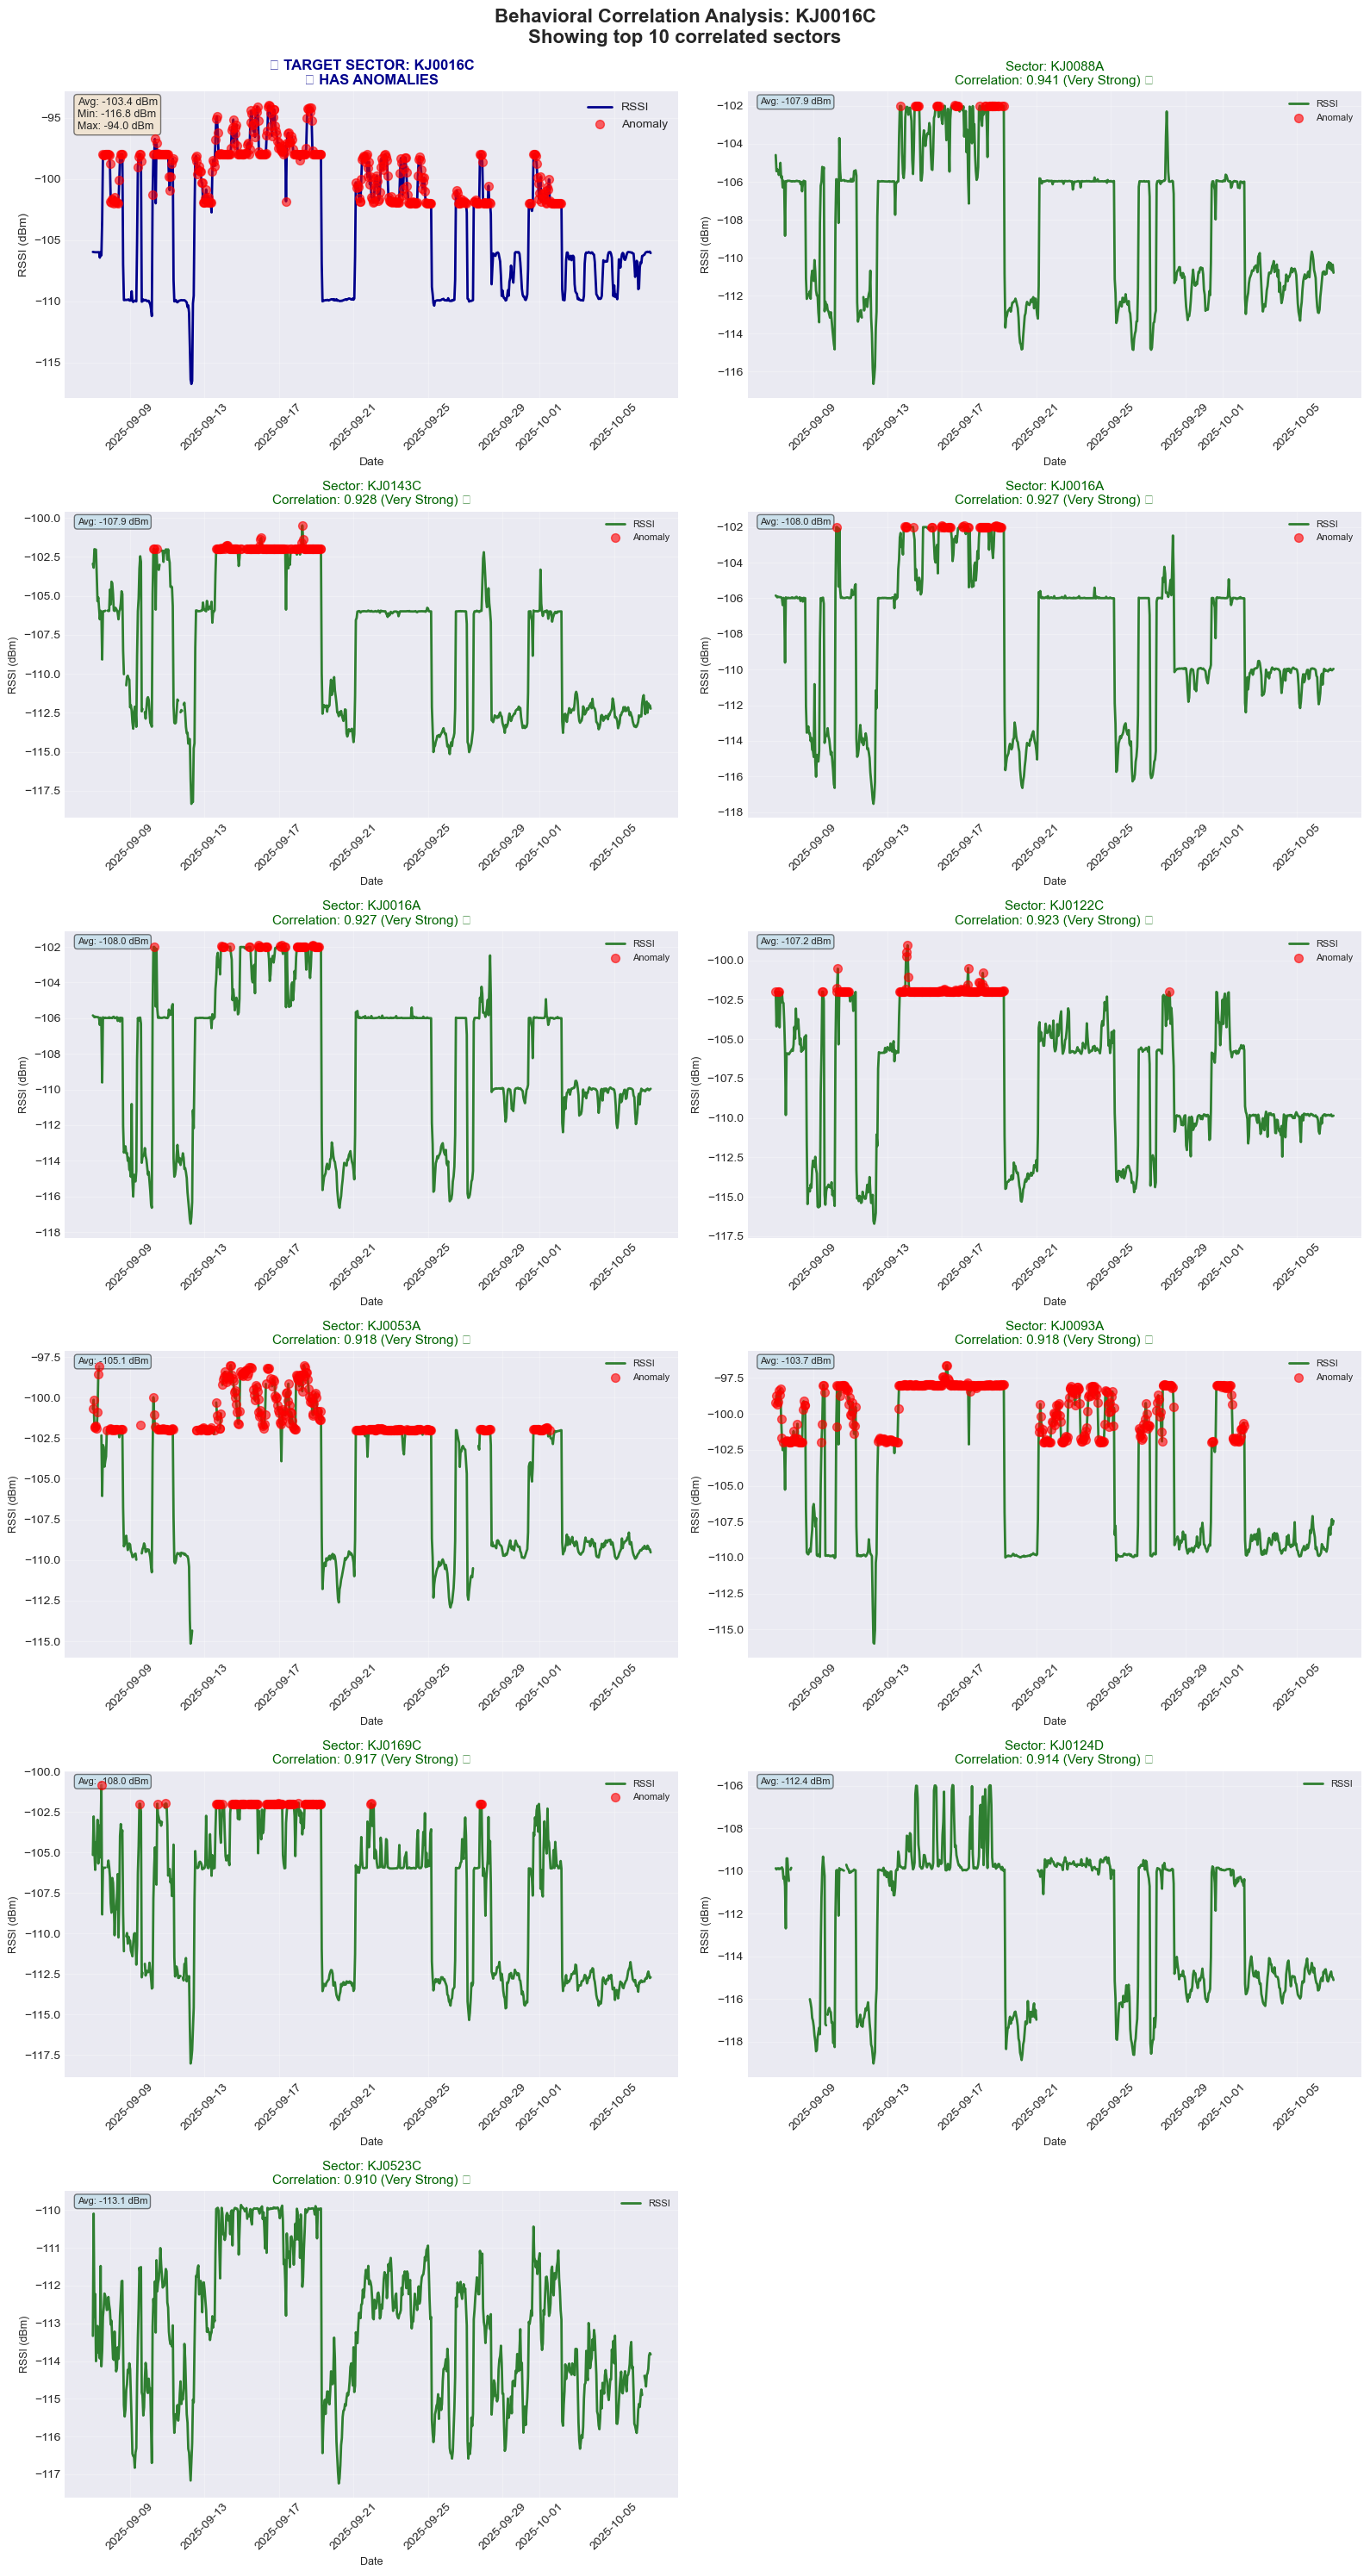


CORRELATION SUMMARY FOR: KJ0016C
  KJ0088A         | Corr: 0.941 | Avg RSSI: -107.9 dBm | ⚠ ANOMALY
  KJ0143C         | Corr: 0.928 | Avg RSSI: -107.9 dBm | ⚠ ANOMALY
  KJ0016A         | Corr: 0.927 | Avg RSSI: -108.0 dBm | ⚠ ANOMALY
  KJ0016A         | Corr: 0.927 | Avg RSSI: -108.0 dBm | ⚠ ANOMALY
  KJ0122C         | Corr: 0.923 | Avg RSSI: -107.2 dBm | ⚠ ANOMALY
  KJ0053A         | Corr: 0.918 | Avg RSSI: -105.1 dBm | ⚠ ANOMALY
  KJ0093A         | Corr: 0.918 | Avg RSSI: -103.7 dBm | ⚠ ANOMALY
  KJ0169C         | Corr: 0.917 | Avg RSSI: -108.0 dBm | ⚠ ANOMALY
  KJ0124D         | Corr: 0.914 | Avg RSSI: -112.4 dBm | ⚠ ANOMALY
  KJ0523C         | Corr: 0.910 | Avg RSSI: -113.1 dBm | ✓ Normal


In [ ]:
#!/usr/bin/env python3
"""
Plot RSSI time series for a sector and all its behaviorally correlated neighbors.
Uses behavioral_connections.csv to find correlated sectors.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

class SectorCorrelationPlotter:
    """Plot RSSI correlations for sectors"""
    
    def __init__(self, data_file, connections_file, results_dir='anomaly_results'):
        """
        Initialize the plotter
        
        Args:
            data_file: Path to main data CSV (with RSSI values)
            connections_file: Path to behavioral_connections.csv
            results_dir: Directory containing analysis results
        """
        self.data_file = data_file
        self.connections_file = connections_file
        self.results_dir = Path(results_dir)
        
        # Load data
        print("Loading data...")
        self.data_df = pd.read_csv(data_file)
        self.data_df['Date'] = pd.to_datetime(self.data_df['Date'])
        
        # Load behavioral connections
        connections_path = self.results_dir / connections_file
        if not connections_path.exists():
            print(f"❌ Error: {connections_path} not found!")
            print("Please run the analysis first to generate behavioral_connections.csv")
            sys.exit(1)
            
        self.connections_df = pd.read_csv(connections_path)
        print(f"✓ Loaded {len(self.connections_df)} behavioral connections")
        print(f"✓ Loaded {len(self.data_df)} data records")
        
    def find_correlated_sectors(self, sector_name):
        """
        Find all sectors correlated with the given sector
        
        Args:
            sector_name: Name of the sector to query
            
        Returns:
            DataFrame with correlated sectors and their info
        """
        # Find connections where sector is either sector_1 or sector_2
        connections = self.connections_df[
            (self.connections_df['sector_1'] == sector_name) | 
            (self.connections_df['sector_2'] == sector_name)
        ].copy()
        
        if len(connections) == 0:
            return None
        
        # Create a list of correlated sectors
        correlated = []
        for _, row in connections.iterrows():
            if row['sector_1'] == sector_name:
                correlated.append({
                    'sector': row['sector_2'],
                    'correlation': row['correlation'],
                    'has_anomaly': row['sector_2_has_anomaly'],
                    'avg_rssi': row['sector_2_avg_rssi']
                })
            else:
                correlated.append({
                    'sector': row['sector_1'],
                    'correlation': row['correlation'],
                    'has_anomaly': row['sector_1_has_anomaly'],
                    'avg_rssi': row['sector_1_avg_rssi']
                })
        
        return pd.DataFrame(correlated).sort_values('correlation', ascending=False)
    
    def plot_sector_and_correlations(self, sector_name, date_range=None, top_n=10, save_path=None):
        """
        Plot RSSI time series for a sector and its correlated neighbors
        
        Args:
            sector_name: Name of the sector to plot
            date_range: Tuple of (start_date, end_date) or None for all dates
            top_n: Number of top correlated sectors to show (default: 10)
            save_path: Path to save the plot (optional)
        """
        # Check if sector exists in data
        if sector_name not in self.data_df['NE'].values:
            print(f"❌ Error: Sector '{sector_name}' not found in data!")
            available_sectors = self.data_df['NE'].unique()[:20]
            print(f"Available sectors (first 20): {', '.join(available_sectors)}")
            return
        
        # Find correlated sectors
        print(f"\n🔍 Finding sectors correlated with '{sector_name}'...")
        correlated_df = self.find_correlated_sectors(sector_name)
        
        if correlated_df is None or len(correlated_df) == 0:
            print(f"⚠ No correlated sectors found for '{sector_name}'")
            print("This sector may not have strong behavioral connections (correlation > 0.7)")
            return
        
        print(f"✓ Found {len(correlated_df)} correlated sectors")
        
        # Limit to top N
        correlated_df = correlated_df.head(top_n)
        
        # Get RSSI data for main sector
        sector_data = self.data_df[self.data_df['NE'] == sector_name].copy()
        
        # Filter by date range if provided
        if date_range:
            start_date, end_date = date_range
            sector_data = sector_data[
                (sector_data['Date'] >= start_date) & 
                (sector_data['Date'] <= end_date)
            ]
        
        sector_data = sector_data.sort_values('Date')
        
        # Create figure with subplots
        n_plots = len(correlated_df) + 1  # +1 for main sector
        n_cols = min(2, n_plots)
        n_rows = (n_plots + n_cols - 1) // n_cols
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
        if n_plots == 1:
            axes = [axes]
        else:
            axes = axes.flatten()
        
        # Plot main sector (first plot)
        ax = axes[0]
        has_anomaly = sector_data['Anomaly'].any() if 'Anomaly' in sector_data.columns else False
        
        # Plot RSSI
        ax.plot(sector_data['Date'], sector_data['RSSI_PUCCH(EUCell_Eric)(CRA)'], 
                linewidth=2, color='darkblue', label='RSSI')
        
        # Highlight anomalies if present
        if 'Anomaly' in sector_data.columns and sector_data['Anomaly'].any():
            anomaly_data = sector_data[sector_data['Anomaly'] == True]
            ax.scatter(anomaly_data['Date'], anomaly_data['RSSI_PUCCH(EUCell_Eric)(CRA)'],
                      color='red', s=50, alpha=0.6, label='Anomaly', zorder=5)
        
        # Styling
        ax.set_title(f"🎯 TARGET SECTOR: {sector_name}\n" + 
                    f"{'⚠ HAS ANOMALIES' if has_anomaly else '✓ No anomalies'}", 
                    fontsize=12, fontweight='bold', color='darkblue')
        ax.set_xlabel('Date', fontsize=10)
        ax.set_ylabel('RSSI (dBm)', fontsize=10)
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='x', rotation=45)
        
        # Add stats text
        stats_text = f"Avg: {sector_data['RSSI_PUCCH(EUCell_Eric)(CRA)'].mean():.1f} dBm\n"
        stats_text += f"Min: {sector_data['RSSI_PUCCH(EUCell_Eric)(CRA)'].min():.1f} dBm\n"
        stats_text += f"Max: {sector_data['RSSI_PUCCH(EUCell_Eric)(CRA)'].max():.1f} dBm"
        ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
               fontsize=9, verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        # Plot correlated sectors
        for idx, (_, corr_info) in enumerate(correlated_df.iterrows(), start=1):
            if idx >= len(axes):
                break
                
            ax = axes[idx]
            corr_sector = corr_info['sector']
            correlation = corr_info['correlation']
            
            # Get data for this correlated sector
            corr_data = self.data_df[self.data_df['NE'] == corr_sector].copy()
            
            # Filter by date range if provided
            if date_range:
                corr_data = corr_data[
                    (corr_data['Date'] >= start_date) & 
                    (corr_data['Date'] <= end_date)
                ]
            
            corr_data = corr_data.sort_values('Date')
            
            if len(corr_data) == 0:
                ax.text(0.5, 0.5, 'No data available', 
                       ha='center', va='center', transform=ax.transAxes)
                ax.set_title(f"{corr_sector}\nCorrelation: {correlation:.3f}")
                continue
            
            # Determine color based on correlation
            if correlation > 0.85:
                color = 'darkgreen'
                strength = 'Very Strong'
            elif correlation > 0.75:
                color = 'green'
                strength = 'Strong'
            else:
                color = 'orange'
                strength = 'Moderate'
            
            # Plot RSSI
            ax.plot(corr_data['Date'], corr_data['RSSI_PUCCH(EUCell_Eric)(CRA)'],
                   linewidth=2, color=color, label='RSSI', alpha=0.8)
            
            # Highlight anomalies if present
            if 'Anomaly' in corr_data.columns and corr_data['Anomaly'].any():
                anomaly_data = corr_data[corr_data['Anomaly'] == True]
                ax.scatter(anomaly_data['Date'], anomaly_data['RSSI_PUCCH(EUCell_Eric)(CRA)'],
                          color='red', s=50, alpha=0.6, label='Anomaly', zorder=5)
            
            # Styling
            has_anomaly = corr_info['has_anomaly']
            ax.set_title(f"Sector: {corr_sector}\n" + 
                        f"Correlation: {correlation:.3f} ({strength}) " +
                        f"{'⚠' if has_anomaly else '✓'}", 
                        fontsize=11, color=color)
            ax.set_xlabel('Date', fontsize=9)
            ax.set_ylabel('RSSI (dBm)', fontsize=9)
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3)
            ax.tick_params(axis='x', rotation=45)
            
            # Add stats
            avg_rssi = corr_data['RSSI_PUCCH(EUCell_Eric)(CRA)'].mean()
            stats_text = f"Avg: {avg_rssi:.1f} dBm"
            ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
                   fontsize=8, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
        
        # Hide unused subplots
        for idx in range(n_plots, len(axes)):
            axes[idx].set_visible(False)
        
        # Overall title
        fig.suptitle(f'Behavioral Correlation Analysis: {sector_name}\n' + 
                    f'Showing top {len(correlated_df)} correlated sectors',
                    fontsize=16, fontweight='bold', y=0.995)
        
        plt.tight_layout()
        
        # Save if requested
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"✓ Plot saved to {save_path}")
        
        # Show plot
        plt.show()
        
        # Print summary
        print("\n" + "="*60)
        print(f"CORRELATION SUMMARY FOR: {sector_name}")
        print("="*60)
        for idx, row in correlated_df.iterrows():
            status = "⚠ ANOMALY" if row['has_anomaly'] else "✓ Normal"
            print(f"  {row['sector']:15} | Corr: {row['correlation']:.3f} | "
                  f"Avg RSSI: {row['avg_rssi']:.1f} dBm | {status}")
        print("="*60)

def main():
    """Main function"""
    print("="*60)
    print("SECTOR BEHAVIORAL CORRELATION PLOTTER")
    print("="*60)
    
    # Configuration - UPDATE THESE PATHS
    data_file = r'C:\Users\USER\Desktop\kasheftest\Git_hub\Kashef_anomaly_detection\data\process\KJ_finalData_102.csv'
    connections_file = r'C:\Users\USER\Desktop\kasheftest\Git_hub\Kashef_anomaly_detection\src\test\anomaly_results\behavioral_connections.csv'
    results_dir = 'anomaly_results_pic'
    
    # Check if data file exists
    if not Path(data_file).exists():
        print(f"❌ Error: Data file not found: {data_file}")
        print("Please update the data_file path in the script.")
        return
    
    # Initialize plotter
    plotter = SectorCorrelationPlotter(data_file, connections_file, results_dir)
    
    sector_name = "KJ0099A"

    # Get sector name from command line or prompt
    '''

    if len(sys.argv) > 1:
        sector_name = sys.argv[1]
    else:
        # Show some example sectors with correlations
        print("\nSample sectors with correlations:")
        sample_sectors = plotter.connections_df['sector_1'].unique()[:10]
        for i, sector in enumerate(sample_sectors, 1):
            print(f"  {i}. {sector}")
        
        print("\nEnter sector name (or press Enter for interactive mode):")
        sector_name = input("> ").strip()
    '''
    if not sector_name:
        print("No sector specified!")
        return
    
    # Optional: Limit date range (uncomment to use)
    # date_range = ('2024-01-01', '2024-01-31')
    date_range = None
    
    # Plot
    print(f"\n📈 Plotting correlations for: {sector_name}")
    
    # Optional: Save to file
    save_path = Path(results_dir) / f'correlation_plot_{sector_name}.png'
    
    plotter.plot_sector_and_correlations(
        sector_name=sector_name,
        date_range=date_range,
        top_n=10,  # Show top 10 correlated sectors
        save_path=save_path
    )

if __name__ == "__main__":
    main()

